# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SimpleRNN, Input
from tensorflow.keras.callbacks import EarlyStopping

# Data Processing

In [ ]:
VOCAB_SIZE = 10000
MAX_LEN = 200
EMBEDDING_DIM = 128
BATCH_SIZE = 64
EPOCHS = 10

In [ ]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [ ]:
!nvidia-smi

Tue Nov 25 02:33:03 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P0             29W /   70W |     394MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

In [ ]:
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 25000
Test samples: 25000


In [ ]:
X_train = pad_sequences(X_train, maxlen = MAX_LEN, padding = 'pre', truncating = 'post')
X_test = pad_sequences(X_test, maxlen = MAX_LEN, padding = 'pre', truncating = 'post')

In [ ]:
print(f"Input shape after padding: {X_train.shape}")

Input shape after padding: (25000, 200)


# Model Building and Training

In [ ]:
def create_model():
    model = Sequential(
        [
            Input(shape = (MAX_LEN, )),
            Embedding(input_dim = VOCAB_SIZE, output_dim = EMBEDDING_DIM),
            SimpleRNN(64, return_sequences = True),
            Dropout(0.5),
            SimpleRNN(64),
            Dropout(0.5),
            Dense(1, activation = 'sigmoid')
        ]
    )

    model.compile(
        optimizer = 'adam',
        loss = 'binary_crossentropy',
        metrics = ['accuracy']
    )

    return model

In [ ]:
model = create_model()

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 200, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,300,673 (4.96 MB)

 Trainable params: 1,300,673 (4.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    validation_data = (X_test, y_test),
    callbacks = [early_stop]
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.5256 - loss: 0.7400 - val_accuracy: 0.7702 - val_loss: 0.5475
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.7449 - loss: 0.5365 - val_accuracy: 0.7515 - val_loss: 0.5203
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.6954 - loss: 0.5709 - val_accuracy: 0.6750 - val_loss: 0.6156
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.6943 - loss: 0.5909 - val_accuracy: 0.7966 - val_loss: 0.4698
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.8135 - loss: 0.4297 - val_accuracy: 0.6475 - val_loss: 0.6559
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.6863 - loss: 0.5953 - val_accuracy: 0.4881 - val_loss: 0.6959
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.5221 - loss: 0.6929 - val_accuracy: 0.4879 - val_loss: 0.6925
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.5364 - loss: 0.6890 - 

#Evaluation

In [ ]:
plt.style.use('dark_background')

In [ ]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label = 'Training Accuracy')
    plt.plot(epochs_range, val_acc, label = 'Validation Accuracy')
    plt.legend(loc = 'lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label = 'Training Loss')
    plt.plot(epochs_range, val_loss, label = 'Validation Loss')
    plt.legend(loc = 'upper right')
    plt.title('Training and Validation Loss')
    plt.show()

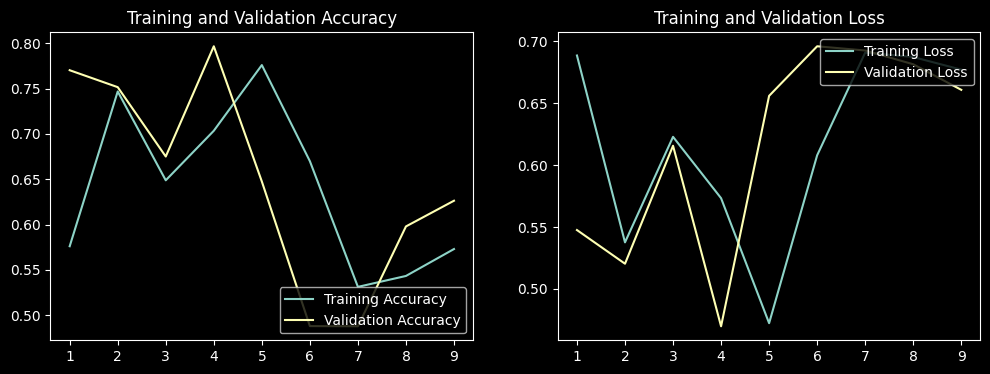

In [ ]:
_ = plot_history(history)

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test, verbose = 0)
print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%")


Final Test Accuracy: 79.66%


In [ ]:
word_index = imdb.get_word_index()

In [ ]:
def predict_custom_review(text):
    tokens = text.lower().split()

    token_indices = [word_index.get(word, 2) + 3 for word in tokens]

    token_indices = [idx if idx < VOCAB_SIZE else 2 for idx in token_indices]

    padded_tokens = pad_sequences([token_indices], maxlen = MAX_LEN, padding = 'pre', truncating = 'post')

    prediction = model.predict(padded_tokens)[0][0]

    print(f"\nReview: \"{text}\"")
    print(f"Confidence: {prediction:.4f}")

    if prediction > 0.5:
        print("Result: POSITIVE")
    else:
        print("Result: NEGATIVE")


In [ ]:
predict_custom_review("This movie was absolutely fantastic and the acting was brilliant")
predict_custom_review("I hated this film it was a complete waste of time and money")
predict_custom_review("The plot was okay but the ending was very disappointing")
predict_custom_review("It was not good")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step

Review: "This movie was absolutely fantastic and the acting was brilliant"
Confidence: 0.9353
Result: POSITIVE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

Review: "I hated this film it was a complete waste of time and money"
Confidence: 0.2572
Result: NEGATIVE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

Review: "The plot was okay but the ending was very disappointing"
Confidence: 0.6808
Result: POSITIVE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Review: "It was not good"
Confidence: 0.9291
Result: POSITIVE
